# Figure 9 of Pierard2024TheTile: No-skill Performances

In [1]:
import matplotlib.pyplot as plt

from sorbetto.annotation import (
    AnnotationCurveFixedClassPriors,
    AnnotationIsovalueCurves,
)
from sorbetto.flavor import BestValueFlavor
from sorbetto.parameterization import ParameterizationDefault
from sorbetto.performance import (
    FiniteSetOfTwoClassClassificationPerformances,
    TwoClassClassificationPerformance,
)
from sorbetto.tile import BestValueTile

In [2]:
def produce_subfigure(prior_pos):
    # The performance of the no-skill classifier always predicting the negative class
    perf_neg = TwoClassClassificationPerformance.getNoSkill(
        priorPos=prior_pos, ratePos=0.0
    )
    # The performance of the no-skill classifier always predicting the positive class
    perf_pos = TwoClassClassificationPerformance.getNoSkill(
        priorPos=prior_pos, ratePos=1.0
    )

    performances = FiniteSetOfTwoClassClassificationPerformances([perf_neg, perf_pos])

    parameterization = ParameterizationDefault()
    flavor = BestValueFlavor(
        performances, name="Value achievable by no-skilled classifiers"
    )
    tile = BestValueTile(
        parameterization,
        flavor,
        name=r"No-skill tile for $\pi_+={:g}$".format(prior_pos),
    )

    annotation = AnnotationIsovalueCurves()
    tile.appendAnnotation(annotation)

    annotation = AnnotationCurveFixedClassPriors(
        prior_pos, linestyle="--", linewidth=2, color="k"
    )
    tile.appendAnnotation(annotation)

    tile.draw()
    plt.show()

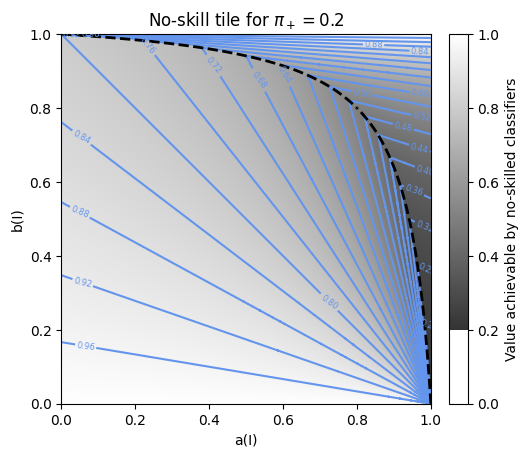

In [3]:
produce_subfigure(0.2)

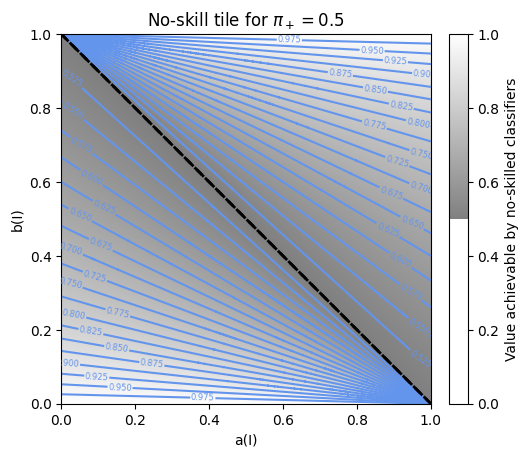

In [4]:
produce_subfigure(0.5)

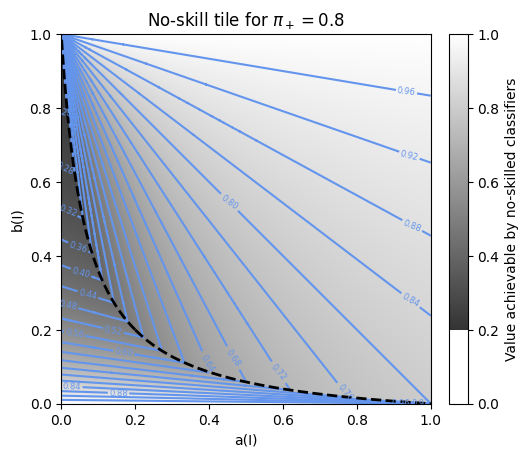

In [5]:
produce_subfigure(0.8)